In [3]:
#import neccessary libraries, with a confirmation message
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
import pickle
import json
from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

print("All imports worked!")


All imports worked!


In [4]:
#read the sataset and print first 10 rows
df = pd.read_csv("dataset.csv")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,NaN,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,NaN,...,Yes,NaN,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,NaN,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,NaN,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
#drop unrelated column, print total number of NaN values for each column
df = df.drop(columns=['customerID'])
print(df.isna().sum())

gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService     207
OnlineSecurity      395
OnlineBackup        275
DeviceProtection      0
TechSupport         693
StreamingTV           0
StreamingMovies       0
Contract            419
PaperlessBilling      0
PaymentMethod        19
MonthlyCharges      545
TotalCharges        276
Churn                 0
dtype: int64


In [6]:
#print how many rows, columns data has
print("Dataset shape:" , df.shape)

Dataset shape: (7043, 20)


In [7]:
#print data types for all columns
print(df.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [8]:
#convert TotalCharges values to numeric data so models can use it 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print(df['TotalCharges'].isna().sum())

287


In [9]:
#fill NaN values with means for numerical features
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].mean())

#fill NaN values with the most frequent values for categorical features
categorical_variables_to_fill = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'Contract']
for var in categorical_variables_to_fill: 
    df[var] = df[var].fillna(df[var].mode()[0])

In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,No,No,Yes,No,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
#check class balance for Churn feature
print(df['Churn'].value_counts(normalize = True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


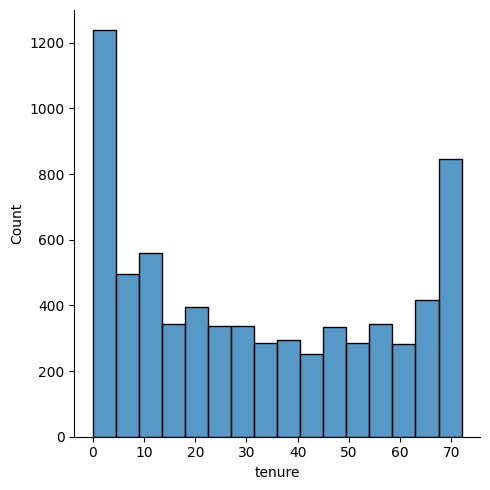

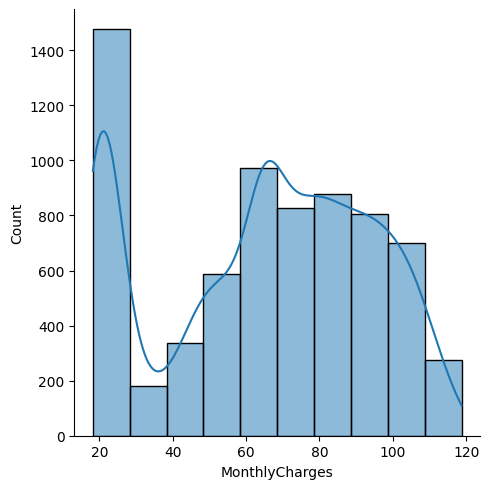

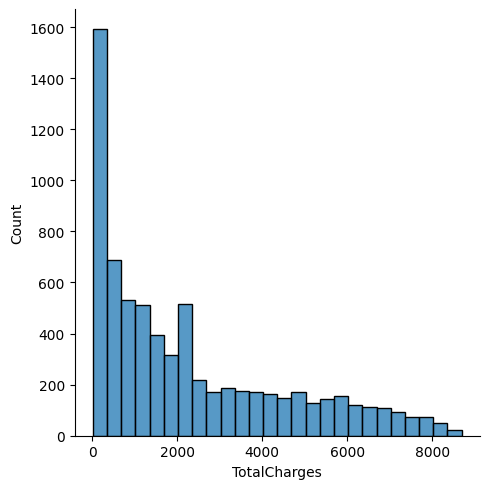

In [12]:
#plot numerical features
sns.displot(df, x = "tenure") 
sns.displot(df, x = "MonthlyCharges", bins = 10, kde = True)
sns.displot(df, x = "TotalCharges")

In [13]:
#check skewness for numerical features
print (df['tenure'].skew())
print(df['MonthlyCharges'].skew())
print(df['TotalCharges'].skew())

0.2395397495619829
-0.2318775046002291
0.9837916022429556


In [14]:
#transform to fix right skewness of this feature (log and log1p didnt work)
df['TotalCharges'] = np.sqrt(df['TotalCharges'])

0.28327047923286847


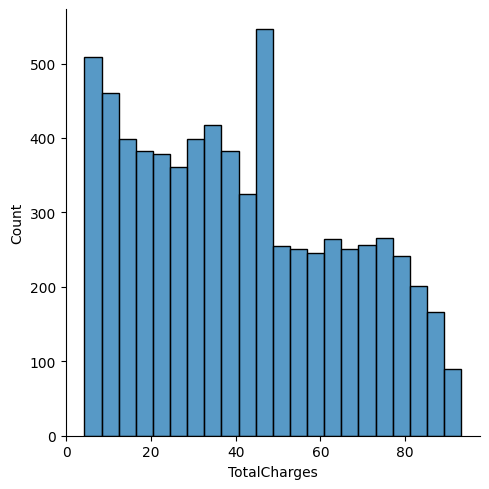

In [15]:
#plot and check skewness again to see difference
sns.displot(df, x = "TotalCharges")
print(df['TotalCharges'].skew())

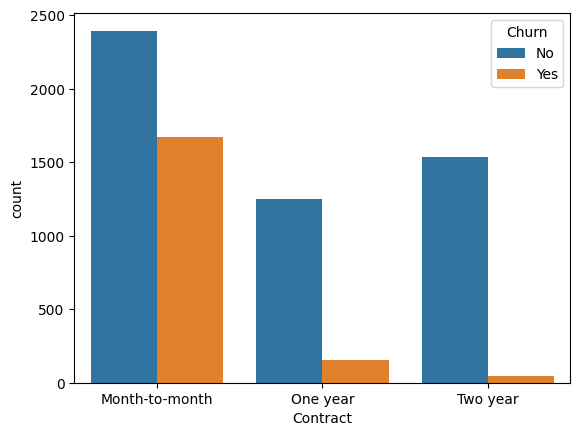

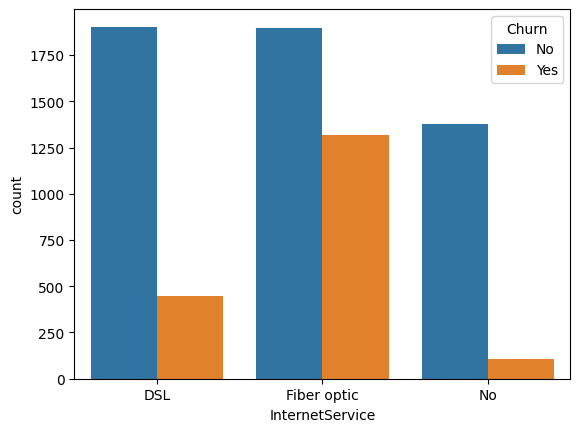

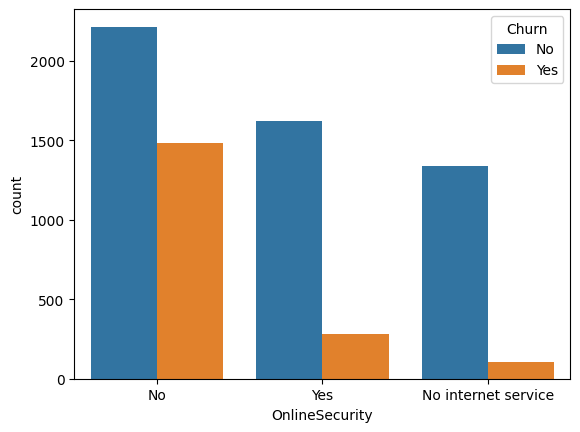

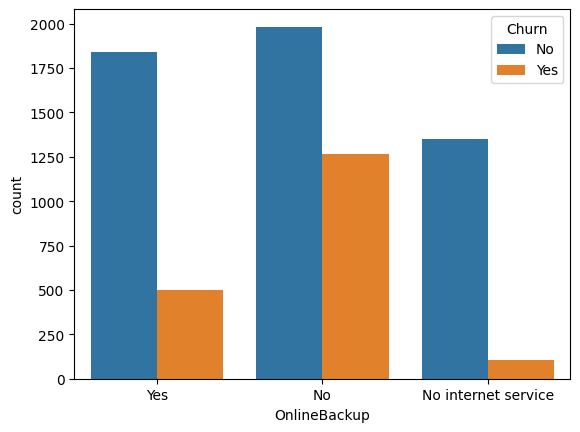

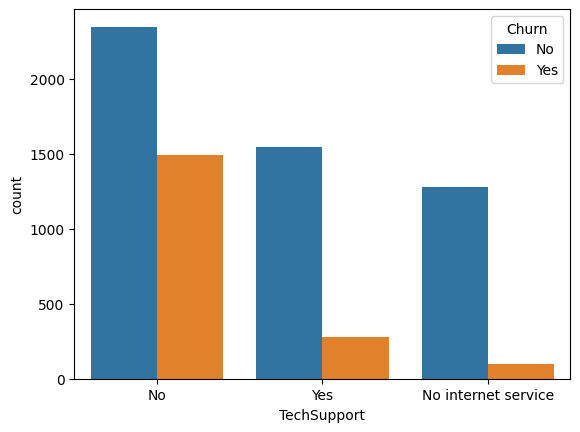

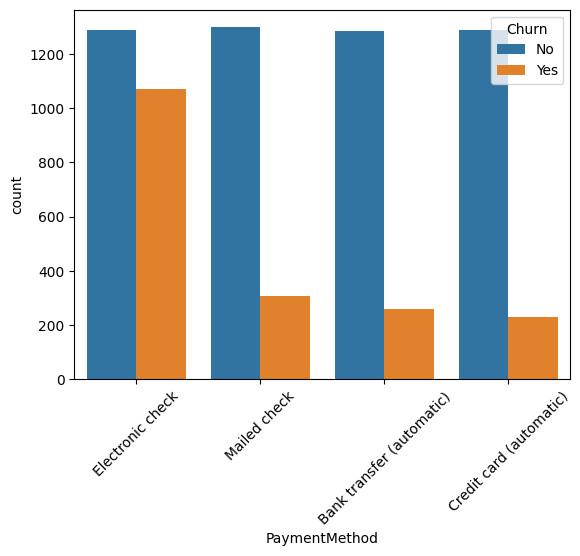

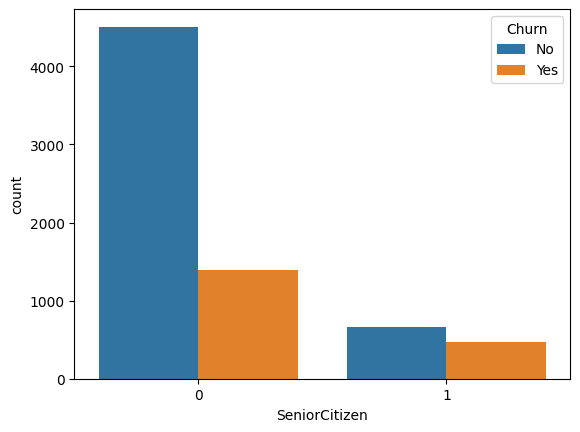

In [16]:
#plot categorical features to figure out relationships
sns.countplot(df, x = 'Contract', hue = 'Churn')
plt.show()
sns.countplot(df, x = 'InternetService', hue = 'Churn')
plt.show()
sns.countplot(df, x = 'OnlineSecurity', hue = 'Churn')
plt.show()
sns.countplot(df, x = 'OnlineBackup', hue = 'Churn')
plt.show()
sns.countplot(df, x = 'TechSupport', hue = 'Churn')
plt.show()
sns.countplot(df, x = 'PaymentMethod', hue = 'Churn')
plt.xticks(rotation = 45)
plt.show()
sns.countplot(df, x = 'SeniorCitizen', hue = 'Churn')
plt.show()

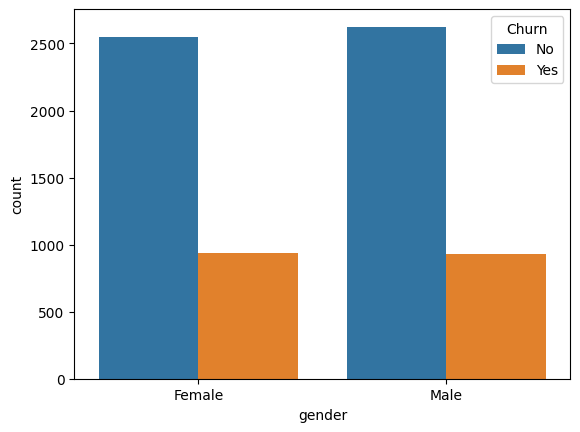

In [17]:
#compared to the ones above this feature doesnt give us as much relevant info
sns.countplot(df, x = 'gender', hue = 'Churn')

#so we can drop it
df = df.drop(columns = ['gender'])

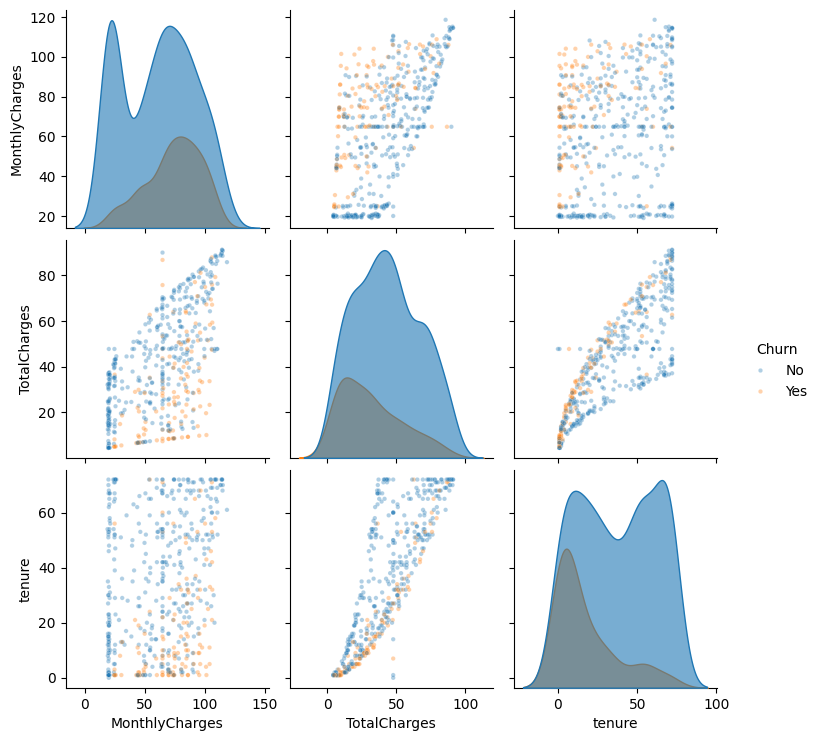

In [19]:
#draw pairwise plots for key features, adjust parameters to make it readable
df_sample = df.sample(n=500, random_state=1)

sns.pairplot(
    df_sample[['MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']],
    hue='Churn',
    plot_kws={'alpha': 0.35, 's': 10},
    diag_kws={'alpha': 0.6}
)


In [ ]:
#create a new feature called 'tenure_group' to make it easier to check how long a customer stayed
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins = [0, 6, 12, 24, 48, 72],
    labels = ['0-6', '7-12', '13-24', '25-48', '49-72'],
    right = True)

print(df[['tenure','tenure_group']])

In [ ]:
#create a new feature called 'num_services' to be able to check wheather the amount of services affect churn
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_services'] = df[service_cols].apply(lambda x: sum(x=='Yes'), axis=1)

In [ ]:
#create a new feature called 'tenure_contract_ratio' to check how nearing the end of a contract affects churn
def contract_length(x):
    if x == 'Month-to-month':
        return 1
    elif x == 'One year':
        return 12
    elif x == 'Two year':
        return 24
        
df['tenure_contract_ratio'] = df['tenure'] / df['Contract'].apply(contract_length)

In [ ]:
#define target and features
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})  #encode as 0/1

#split the dataset
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.05, stratify=y, random_state=42
)

In [ ]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'tenure_contract_ratio']
categorical_features = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 
                        'PaymentMethod', 'tenure_group']

#transform the feature matrix ready for training
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

In [ ]:
#choose five algorithms
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=1000, random_state=42)
}

#wrap each model in a pipeline with the preprocessor
pipelines = {name: Pipeline([('preprocessor', preprocessor), ('model', model)]) 
             for name, model in models.items()}

In [ ]:
#parameters for the folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

#create array to store results
results = []

#calculate avarage for each metric across 5 folds for all models
for name, pipeline in pipelines.items():
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
    results.append({
        'Model': name,
        'Accuracy': cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'F1': cv_results['test_f1'].mean(),
        'ROC_AUC': cv_results['test_roc_auc'].mean()
    })

#create a new data frame to display results
results_df = pd.DataFrame(results).sort_values(by='ROC_AUC', ascending=False)
print(results_df)

In [20]:
#create bar plots
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']

for metric in metrics:
    sns.barplot(data=results_df, x='Model', y=metric)
    plt.ylim(0,1)
    plt.xticks(rotation=45)
    plt.show()

NameError: name 'results_df' is not defined

In [ ]:
#best scrore of roc auc, train for the %95
best_pipeline = pipelines["Logistic Regression"]

#wrap only the model inside the pipeline with calibration
best_pipeline.named_steps['model'] = CalibratedClassifierCV(
    best_pipeline.named_steps['model'], cv=5
)

#train on the %95
best_pipeline.fit(X_train, y_train)

In [ ]:
#serialize to model.pkl
with open("model.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

print("Pipeline saved to model.pkl")

In [ ]:
#build a feature schema
feature_schema = {col: str(X[col].dtype) for col in X.columns}

#save to JSON
with open("feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=4)

print("Feature schema saved to feature_schema.json")

In [ ]:
#calculate permutation importance to find the most important feature
result = permutation_importance(
    best_pipeline, X_train, y_train,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

#visualize
plt.barh(X_train.columns, result.importances_mean)
plt.show()